# Módulo 5 · Introducción a los modelos AR: simulación e intuición

Curso: **Series Temporales con R y Python** (Frogames Formación).

Notebook de acompañamiento de la lección `05-modelos-ar/01-introduccion-a-los-modelos-ar` — ábrelo mientras lees la lección y ejecuta cada celda tú mismo.

Este notebook no parte de un dataset real: **simula** procesos AR(1) con distintos valores de $\phi$ para que veas, con tus propios ojos, cómo la notación se traduce en comportamiento. La lección siguiente ya trabaja sobre precios reales.

In [1]:
import matplotlib.pyplot as plt

# Estilo oscuro opcional, para que los gráficos combinen con el tema del curso.
# No afecta a ningún resultado numérico -- puedes omitir esta celda sin problema.
plt.rcParams.update({
    "figure.facecolor": "#0d0d10", "axes.facecolor": "#0d0d10",
    "axes.edgecolor": "#a8a8b3", "axes.labelcolor": "#e1e1e6",
    "xtick.color": "#a8a8b3", "ytick.color": "#a8a8b3",
    "text.color": "#e1e1e6", "grid.color": "#232326",
    "font.size": 11,
})

## Simular tres procesos AR(1) con distinto $\phi$

Un AR(1) se define como $Y_t = c + \phi Y_{t-1} + \varepsilon_t$, con $\varepsilon_t$ ruido blanco. `ArmaProcess` de `statsmodels` usa el polinomio autorregresivo con el signo invertido: para $\phi$ pasamos `ar = [1, -phi]`.

In [2]:
import numpy as np
from statsmodels.tsa.arima_process import ArmaProcess

np.random.seed(42)
n = 200

phis = [0.2, 0.7, 0.95]
series = {}
for phi in phis:
    ar = np.array([1, -phi])
    ma = np.array([1])
    process = ArmaProcess(ar, ma)
    series[phi] = process.generate_sample(nsample=n)
    print(f"phi={phi}: media={series[phi].mean():.4f}  std={series[phi].std():.4f}")

phi=0.2: media=-0.0495  std=0.9363
phi=0.7: media=0.2694  std=1.3256
phi=0.95: media=-1.6750  std=2.7301


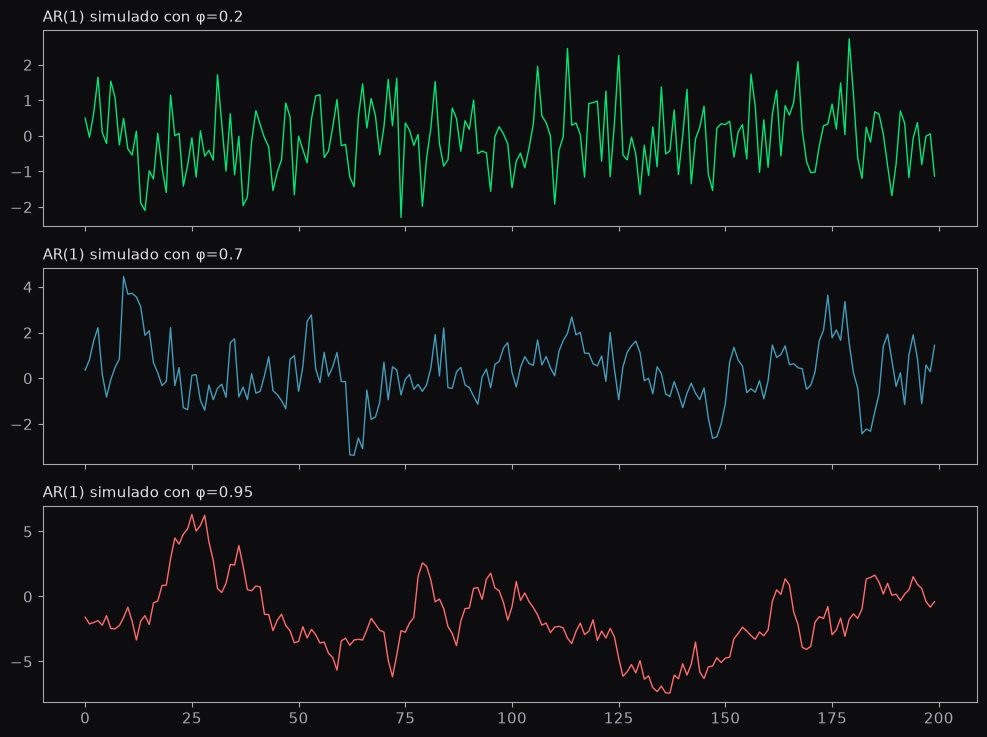

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7.5), sharex=True)
colors = ["#00e676", "#449cb9", "#ff6b6b"]
for ax, phi, color in zip(axes, phis, colors):
    ax.plot(series[phi], color=color, linewidth=1)
    ax.set_title(f"AR(1) simulado con φ={phi}", loc="left", fontsize=11)
plt.tight_layout()
plt.show()

## Autocorrelación teórica de un AR(1)

Para un AR(1) estacionario, $\rho_k = \phi^k$: la autocorrelación decae geométricamente. Cuanto más cerca de 1 está $\phi$, más lento el decaimiento — más "memoria" tiene la serie.

In [4]:
for phi in phis:
    rhos = [phi**k for k in range(6)]
    print(f"phi={phi}: rho_0..rho_5 =", [round(r, 4) for r in rhos])

phi=0.2: rho_0..rho_5 = [1.0, 0.2, 0.04, 0.008, 0.0016, 0.0003]
phi=0.7: rho_0..rho_5 = [1.0, 0.7, 0.49, 0.343, 0.2401, 0.1681]
phi=0.95: rho_0..rho_5 = [1.0, 0.95, 0.9025, 0.8574, 0.8145, 0.7738]


## ACF empírica de las tres series simuladas

Comprobamos que la ACF muestral de cada serie simulada reproduce el decaimiento teórico $\phi^k$ de la celda anterior.

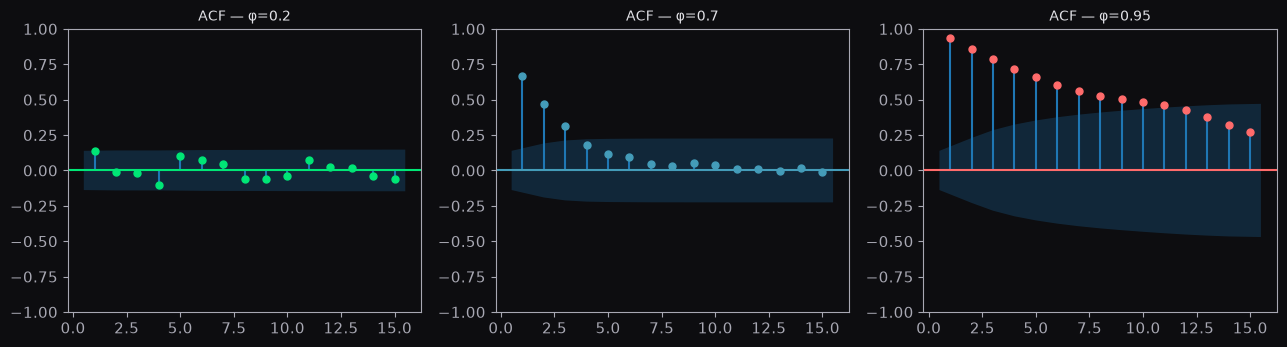

In [5]:
import statsmodels.graphics.tsaplots as sgt

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, phi, color in zip(axes, phis, colors):
    sgt.plot_acf(series[phi], lags=15, zero=False, ax=ax, color=color)
    ax.set_title(f"ACF — φ={phi}", fontsize=10)
plt.tight_layout()
plt.show()

**Entregable**: reproduce estas celdas y añade un cuarto caso con $\phi = -0.6$ (autocorrelación negativa). Compara su gráfico de serie y su ACF contra los tres casos positivos: ¿qué patrón visual delata que $\phi$ es negativo, incluso antes de mirar el valor numérico?